# 1-Photon Calcium Imaging Binarization Pipeline

Demonstrates binarizing one-photon (Inscopix / fibre photometry) calcium data
using `binarize2pcalcium`.  Uses the built-in simulation module with realistic
GCaMP kinetics configured for noisier 1P recordings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from binarize2pcalcium import binarize, BinarizationResult
from binarize2pcalcium.data_simulation import (
    SimulationConfig,
    simulate_calcium_data,
    simulate_and_binarize,
)

print("Setup complete.")

Setup complete.


## 1. Simulate realistic 1P data

1P settings: 20 Hz, slower GCaMP, lower photon counts → more shot noise.

In [2]:
cfg = SimulationConfig(
    n_cells=25,
    n_timepoints=6000,        # 5 min @ 20 Hz
    sample_rate=20.0,
    tau_rise_mean=0.12,       # slightly slower rise
    tau_decay_mean=1.0,       # slower GCaMP
    amplitude_mean=0.25,
    baseline_photons=150.0,   # lower photon count
    read_noise_std=6.0,       # higher read noise
    event_rate=0.03,
    drift_scale=0.03,         # more baseline drift
    seed=42,
)

F_noisy, dff_true = simulate_calcium_data(cfg)
print(f"F shape: {F_noisy.shape}")

F shape: (25, 6000)


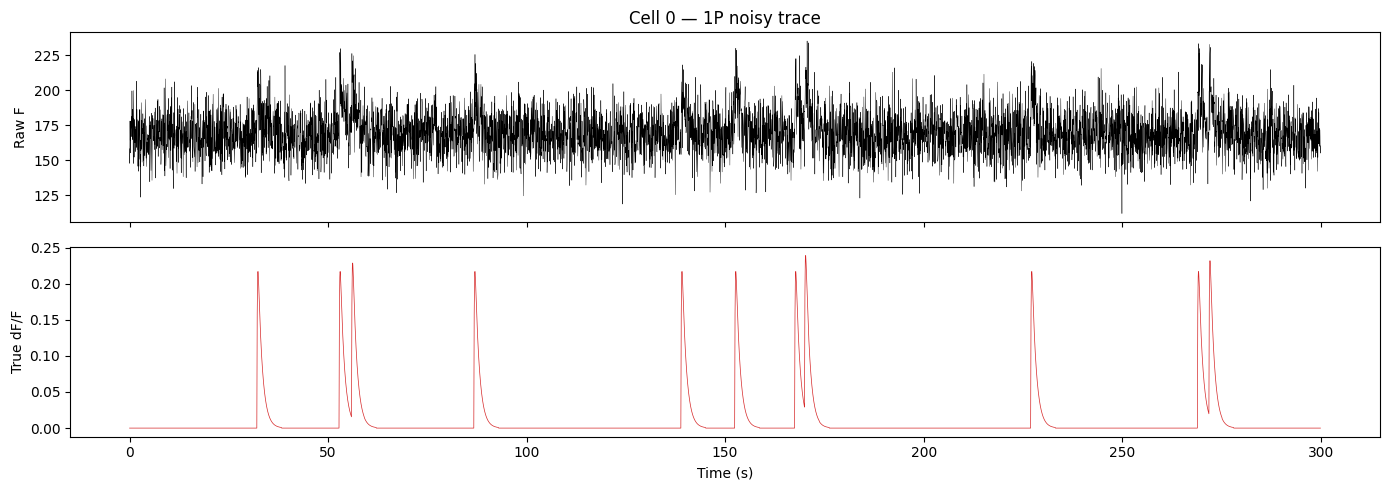

In [3]:
cell_id = 0
t = np.arange(cfg.n_timepoints) / cfg.sample_rate
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(t, F_noisy[cell_id], linewidth=0.3, color='k')
ax1.set_ylabel('Raw F'); ax1.set_title(f'Cell {cell_id} — 1P noisy trace')
ax2.plot(t, dff_true[cell_id], linewidth=0.5, color='C3')
ax2.set_ylabel('True dF/F'); ax2.set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

## 2. Binarize with 1P parameters

In [4]:
result, event_gt, dff_clean = simulate_and_binarize(cfg, binarize_kwargs=dict(
    data_type='1p',                # F - F0 instead of F / F0
    high_cutoff=1.0,               # 1P default from source
    percentile_threshold=0.999,
    dff_min=0.10,                  # 1P default from source
    verbose=True,
))

print(f"Onphase: {result.onphase.sum():,}  |  Upphase: {result.upphase.sum():,}  |  GT: {event_gt.sum():,}")

Running binarization pipeline:
  data_type=1p, sample_rate=20.0 Hz
  high_cutoff=1.0 Hz, detrend_order=1
  Input shape: (25, 6000)


model filter: remove bleaching or trends: 100%|██████████| 25/25 [00:00<00:00, 1836.90it/s]


  Computing thresholds...


fitting mode to physics: 100%|██████████| 25/25 [00:00<00:00, 116.31it/s]


  Binarizing onphase...


binarizing continuous traces: 100%|██████████| 25/25 [00:00<00:00, 14725.12it/s]


  Binarizing upphase...


binarizing continuous traces: 100%|██████████| 25/25 [00:00<00:00, 11860.38it/s]

  Done. Onphase events: 2032, Upphase events: 455
Onphase: 2,032.0  |  Upphase: 455.0  |  GT: 12,801


## 3. Single-cell visualisation

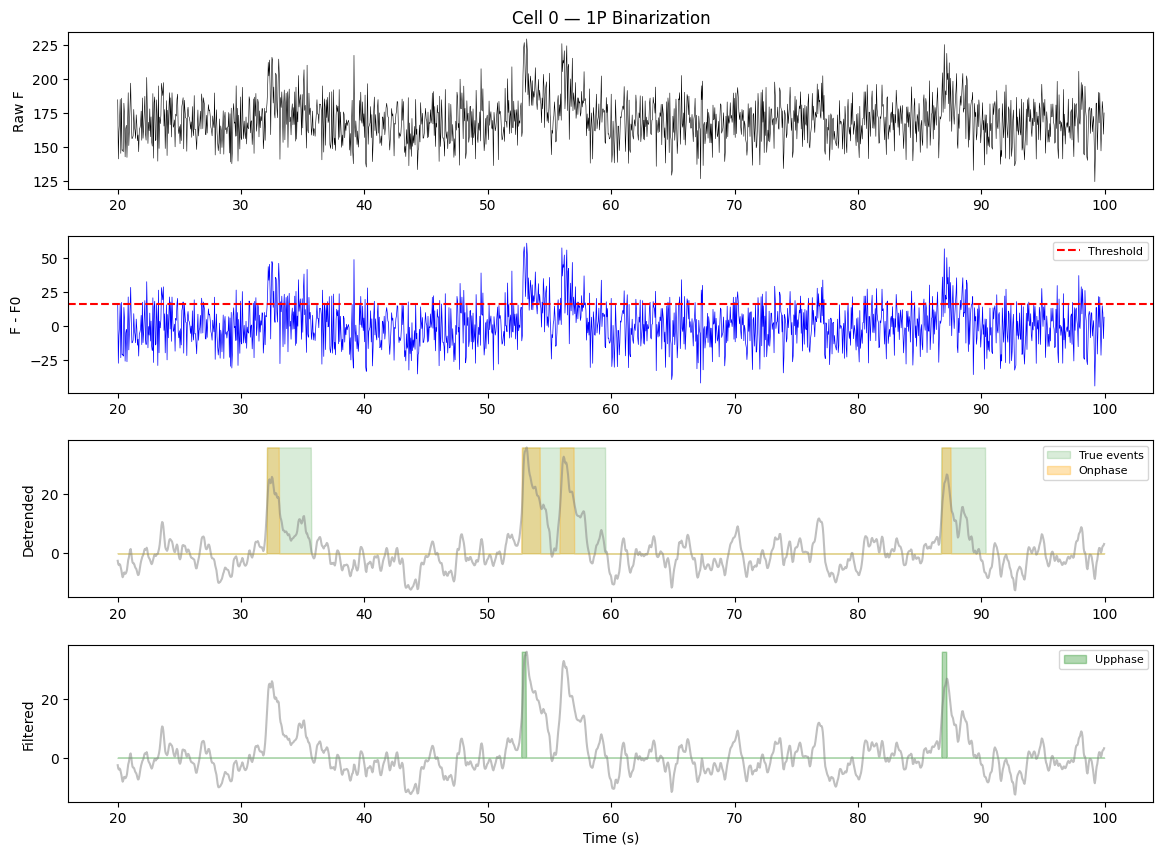

In [5]:
cell_id = 0
t = np.arange(result.F_raw.shape[1]) / cfg.sample_rate
zoom = slice(400, 2000)

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(4, 1, figure=fig, hspace=0.3)

ax0 = fig.add_subplot(gs[0])
ax0.plot(t[zoom], result.F_raw[cell_id, zoom], 'k', linewidth=0.4)
ax0.set_ylabel('Raw F'); ax0.set_title(f'Cell {cell_id} — 1P Binarization')

ax1 = fig.add_subplot(gs[1])
ax1.plot(t[zoom], result.dff[cell_id, zoom], 'b', linewidth=0.5)
ax1.axhline(y=result.thresholds[cell_id], color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('F - F0'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[2])
ymax = result.F_detrended[cell_id, zoom].max()
ax2.plot(t[zoom], result.F_detrended[cell_id, zoom], 'gray', alpha=0.5)
ax2.fill_between(t[zoom], 0, event_gt[cell_id, zoom] * ymax,
                 alpha=0.15, color='green', label='True events')
ax2.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='orange', label='Onphase')
ax2.set_ylabel('Detrended'); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[3])
ymax = result.F_filtered[cell_id, zoom].max()
ax3.plot(t[zoom], result.F_filtered[cell_id, zoom], 'gray', alpha=0.5)
ax3.fill_between(t[zoom], 0, result.upphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='green', label='Upphase')
ax3.set_ylabel('Filtered'); ax3.set_xlabel('Time (s)')
ax3.legend(fontsize=8)

plt.show()

## 4. Raster plot

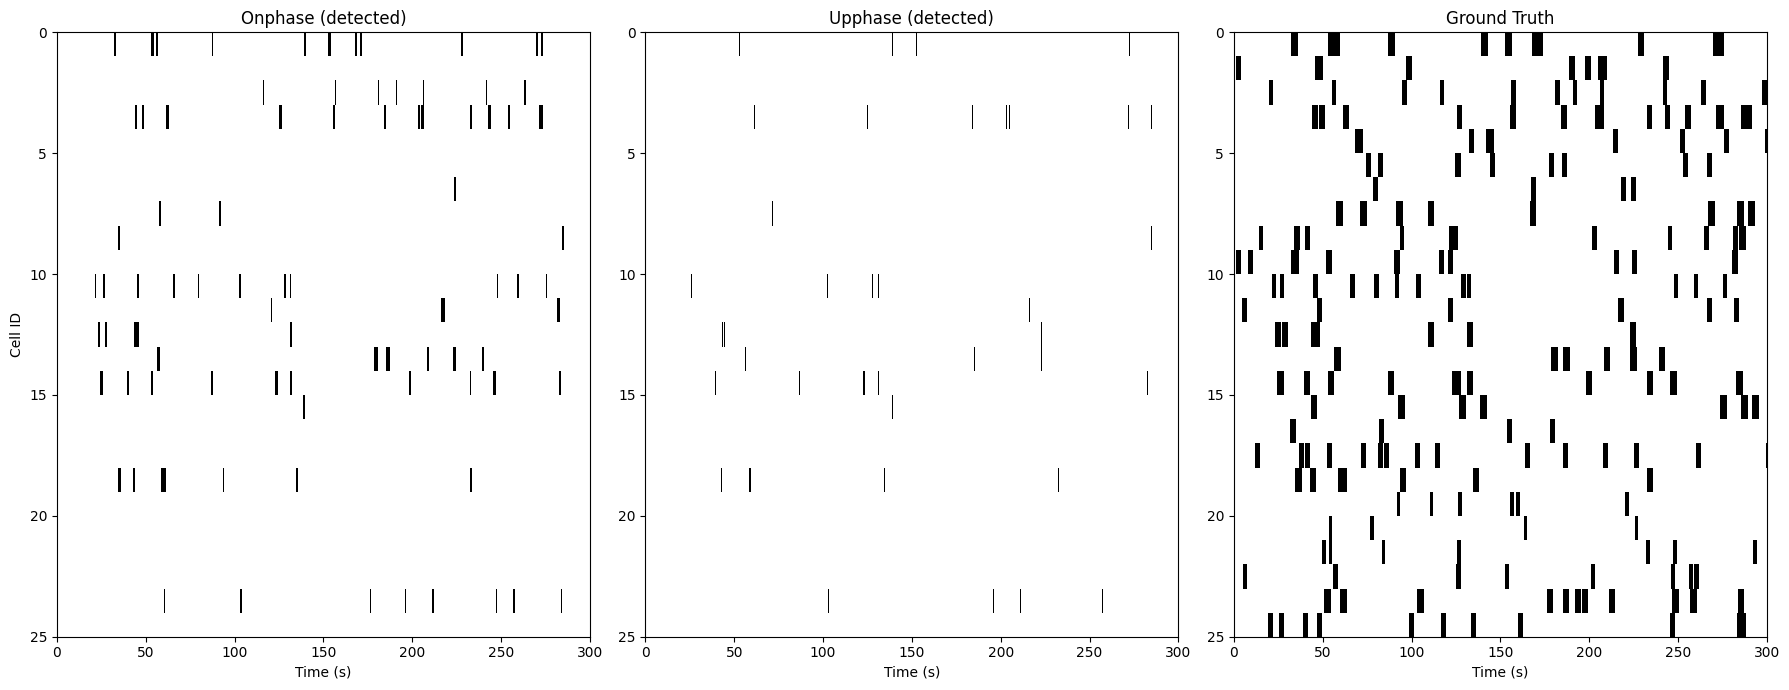

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, data, title in zip(axes,
    [result.onphase, result.upphase, event_gt],
    ['Onphase (detected)', 'Upphase (detected)', 'Ground Truth']):
    ax.imshow(data, aspect='auto', cmap='Greys', interpolation='none',
              extent=[0, data.shape[1] / cfg.sample_rate, data.shape[0], 0])
    ax.set_xlabel('Time (s)'); ax.set_title(title)
axes[0].set_ylabel('Cell ID')
plt.tight_layout(); plt.show()

## 5. Using a config file

In [8]:
import yaml
with open('../config/1p_pipeline.yaml') as f:
    params = yaml.safe_load(f)
result = binarize(F_noisy, **{k: v for k, v in params.items() if v is not None})
print(f"Used config: sample_rate={params['sample_rate']} Hz")

binarizing continuous traces: 100%|██████████| 25/25 [00:00<00:00, 14358.15it/s]

Used config: sample_rate=20 Hz
